# Turing Patterns: Reaction-Diffusion Systems

In 1952, Alan Turing proposed a surprising idea: a perfectly uniform surface can form stripes, spots, and fingerprint-like ridges if two chemicals react and diffuse at different rates.

The model became a bridge between computation, chemistry, and biology. It gives one mathematical story for animal coats, seashell bands, vegetation patterns, and other cases where local interactions produce visible structure.

This notebook builds that idea with NumPy arrays. We will simulate an **activator** and an **inhibitor** spreading across a 2D surface, then watch random static become organic patterns.

<details>
<summary>Big idea</summary>

A local reaction changes chemical amounts at each cell. Diffusion spreads those chemicals to neighboring cells. When the two processes interact, order can emerge from noise.

</details>

## 1. The Mental Model

A reaction-diffusion system has two forces:

- **Reaction**: chemicals create, consume, or transform each other locally.
- **Diffusion**: chemicals spread from each cell to nearby cells.

We will use a classic Gray-Scott style model:

- `A` acts like a background chemical.
- `B` acts like a pattern-forming activator.
- `A` and `B` react through `A * B * B`.
- `A` and `B` diffuse at different speeds.

<details>
<summary>Discrete Laplacian hint</summary>

The Laplacian is a neighbor comparison. If a cell has more chemical than its neighbors, diffusion pushes chemical outward. If it has less, diffusion pulls chemical inward.

</details>

## 2. Build the Objects

Implementation plan:

1. `ReactionParameters` stores diffusion, feed, and kill rates.
2. `PatternSnapshot` stores one saved simulation frame.
3. `ReactionDiffusionGrid` owns the `A` and `B` arrays.
4. `TuringPatternRunner` advances the system and records snapshots.
5. `PatternReplay` prints numerical summaries.

<details>
<summary>Implementation hint</summary>

The update happens to the whole grid at once. We compute the next `A` and `B` arrays from the old arrays, then replace them together.

</details>

**Trace model.** Define `ReactionParameters`, `PatternSnapshot`, the structure used to capture replayable algorithm state.


In [ ]:
from dataclasses import dataclass

import numpy as np

import matplotlib.pyplot as plt

from matplotlib import animation

from IPython.display import HTML

@dataclass(frozen=True)
class ReactionParameters:
    diffusion_a: float
    diffusion_b: float
    feed_rate: float
    kill_rate: float
    name: str = "pattern"

@dataclass(frozen=True)
class PatternSnapshot:
    step: int
    activator: np.ndarray
    inhibitor: np.ndarray
    note: str

    def contrast(self) -> float:
        return float(self.inhibitor.max() - self.inhibitor.min())


**State model.** Define `ReactionDiffusionGrid`, the data structure the lesson will operate on.


In [ ]:
class ReactionDiffusionGrid:
    def __init__(self, size: int, parameters: ReactionParameters, seed: int = 8):
        self.size = size
        self.parameters = parameters
        self.rng = np.random.default_rng(seed)
        self.activator = np.ones((size, size), dtype=float)
        self.inhibitor = np.zeros((size, size), dtype=float)
        self._seed_noise()

    def _seed_noise(self) -> None:
        center = self.size // 2
        radius = self.size // 10
        square = slice(center - radius, center + radius)

        self.activator += 0.02 * self.rng.random((self.size, self.size))
        self.inhibitor += 0.02 * self.rng.random((self.size, self.size))
        self.activator[square, square] = 0.50
        self.inhibitor[square, square] = 0.25

    def laplacian(self, grid: np.ndarray) -> np.ndarray:
        return (
            -grid
            + 0.20 * (
                np.roll(grid, 1, axis=0)
                + np.roll(grid, -1, axis=0)
                + np.roll(grid, 1, axis=1)
                + np.roll(grid, -1, axis=1)
            )
            + 0.05 * (
                np.roll(np.roll(grid, 1, axis=0), 1, axis=1)
                + np.roll(np.roll(grid, 1, axis=0), -1, axis=1)
                + np.roll(np.roll(grid, -1, axis=0), 1, axis=1)
                + np.roll(np.roll(grid, -1, axis=0), -1, axis=1)
            )
        )

    def step(self, dt: float = 1.0) -> None:
        params = self.parameters
        a = self.activator
        b = self.inhibitor
        reaction = a * b * b

        next_a = a + (
            params.diffusion_a * self.laplacian(a)
            - reaction
            + params.feed_rate * (1 - a)
        ) * dt
        next_b = b + (
            params.diffusion_b * self.laplacian(b)
            + reaction
            - (params.kill_rate + params.feed_rate) * b
        ) * dt

        self.activator = np.clip(next_a, 0, 1)
        self.inhibitor = np.clip(next_b, 0, 1)

    def snapshot(self, step: int, note: str) -> PatternSnapshot:
        return PatternSnapshot(
            step=step,
            activator=self.activator.copy(),
            inhibitor=self.inhibitor.copy(),
            note=note,
        )


**Algorithm engine.** Define `TuringPatternRunner`, the class that runs the main simulation or algorithm.


In [ ]:
class TuringPatternRunner:
    def __init__(self, grid: ReactionDiffusionGrid):
        self.grid = grid

    def run(self, total_steps: int, capture_every: int = 50) -> list[PatternSnapshot]:
        snapshots = [self.grid.snapshot(0, "Random noise with a small center disturbance.")]

        for step in range(1, total_steps + 1):
            self.grid.step()
            if step % capture_every == 0 or step == total_steps:
                snapshots.append(self.grid.snapshot(step, "Reaction and diffusion have reshaped the chemicals."))

        return snapshots


In [6]:
def scatter_chemical_noise(grid: ReactionDiffusionGrid, spots: int = 55, seed: int = 99) -> None:
    rng = np.random.default_rng(seed)
    size = grid.size
    yy, xx = np.ogrid[:size, :size]

    grid.activator = 1.0 + 0.015 * rng.random((size, size))
    grid.inhibitor = 0.02 * rng.random((size, size))

    for _ in range(spots):
        center_y = rng.integers(5, size - 5)
        center_x = rng.integers(5, size - 5)
        radius = rng.integers(2, 5)
        mask = (yy - center_y) ** 2 + (xx - center_x) ** 2 <= radius ** 2
        grid.activator[mask] = rng.uniform(0.35, 0.70)
        grid.inhibitor[mask] = rng.uniform(0.18, 0.36)

    grid.activator = np.clip(grid.activator, 0, 1)
    grid.inhibitor = np.clip(grid.inhibitor, 0, 1)

## 3. Run the Reaction-Diffusion System

We start with mostly uniform chemicals and a small patch of noise. Then each step applies:

```text
new amount = old amount + diffusion + reaction
```

The inhibitor field is what we will visualize because it forms the most visible ridges and spots.

<details>
<summary>Parameter hint</summary>

Small changes to feed and kill rates can shift the pattern from dots to stripes to maze-like ridges.

</details>

In [7]:
stripe_parameters = ReactionParameters(
    diffusion_a=0.16,
    diffusion_b=0.08,
    feed_rate=0.030,
    kill_rate=0.058,
    name="maze-like ridges",
)

grid = ReactionDiffusionGrid(size=96, parameters=stripe_parameters, seed=12)
scatter_chemical_noise(grid, spots=70, seed=44)
runner = TuringPatternRunner(grid)
snapshots = runner.run(total_steps=900, capture_every=150)

print(f"Pattern style: {stripe_parameters.name}")
print(f"Captured snapshots: {len(snapshots)}")
print(f"Final contrast: {snapshots[-1].contrast():.3f}")
print(f"Final inhibitor mean: {snapshots[-1].inhibitor.mean():.3f}")

Pattern style: maze-like ridges
Captured snapshots: 7
Final contrast: 0.407
Final inhibitor mean: 0.148


## 4. Replay the Pattern Growth

Snapshots show the system moving from noisy chemistry toward organized structure.

<details>
<summary>Reading contrast</summary>

Higher contrast means the inhibitor field has stronger light/dark separation. That usually means the pattern is becoming easier to see.

</details>

In [13]:
class PatternReplay:
    def __init__(self, snapshots: list[PatternSnapshot]):
        self.snapshots = snapshots

    def show(self) -> None:
        for snapshot in self.snapshots:
            note = "Scattered chemical noise across the grid." if snapshot.step == 0 else snapshot.note
            print(
                f"step={snapshot.step:>4} "
                f"inhibitor_mean={snapshot.inhibitor.mean():.3f} "
                f"contrast={snapshot.contrast():.3f} | {note}"
            )


PatternReplay(snapshots).show()

step=   0 inhibitor_mean=0.065 contrast=0.352 | Scattered chemical noise across the grid.
step= 150 inhibitor_mean=0.087 contrast=0.447 | Reaction and diffusion have reshaped the chemicals.
step= 300 inhibitor_mean=0.110 contrast=0.440 | Reaction and diffusion have reshaped the chemicals.
step= 450 inhibitor_mean=0.124 contrast=0.407 | Reaction and diffusion have reshaped the chemicals.
step= 600 inhibitor_mean=0.135 contrast=0.420 | Reaction and diffusion have reshaped the chemicals.
step= 750 inhibitor_mean=0.142 contrast=0.410 | Reaction and diffusion have reshaped the chemicals.
step= 900 inhibitor_mean=0.148 contrast=0.407 | Reaction and diffusion have reshaped the chemicals.


## 5. Plot the Pattern Snapshots

Now we turn the inhibitor array into an image. Light and dark regions show different chemical concentrations.

<details>
<summary>Why visualize the inhibitor?</summary>

In the Gray-Scott model, the `B` chemical often creates the clearest visible ridges, spots, and maze-like structures.

</details>

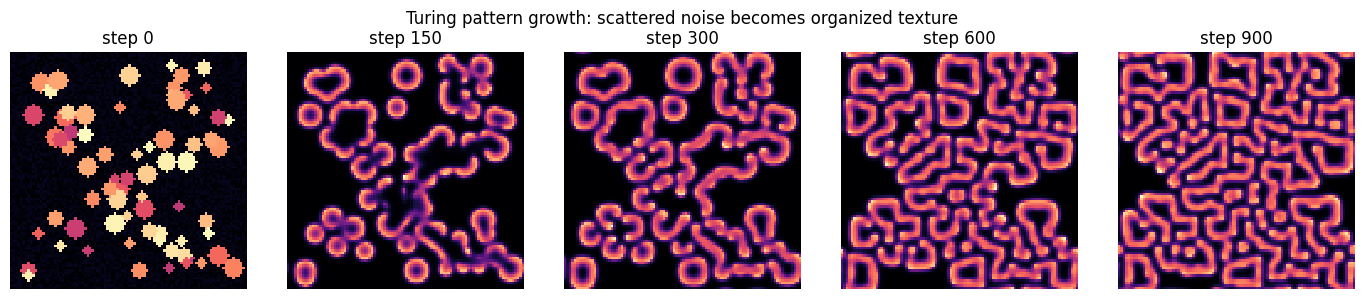

In [9]:
selected_snapshots = [snapshots[index] for index in [0, 1, 2, 4, 6]]

fig, axes = plt.subplots(1, len(selected_snapshots), figsize=(14, 3))
for axis, snapshot in zip(axes, selected_snapshots):
    axis.imshow(snapshot.inhibitor, cmap="magma", interpolation="nearest")
    axis.set_title(f"step {snapshot.step}")
    axis.axis("off")

fig.suptitle("Turing pattern growth: scattered noise becomes organized texture", fontsize=12)
plt.tight_layout()
plt.show()

## 6. Animate the Pattern

Matplotlib can animate the saved snapshots. The animation is intentionally short so it runs comfortably in a notebook.

<details>
<summary>Animation hint</summary>

A real-time animation would update every simulation step. Here we animate captured snapshots so the notebook stays lightweight.

</details>

In [11]:
fig, axis = plt.subplots(figsize=(5, 5))
image = axis.imshow(snapshots[0].inhibitor, cmap="magma", interpolation="nearest", animated=True)
title = axis.set_title("step 0")
axis.axis("off")


def update_frame(frame_index: int):
    snapshot = snapshots[frame_index]
    image.set_array(snapshot.inhibitor)
    title.set_text(f"step {snapshot.step}")
    return image, title


pattern_animation = animation.FuncAnimation(
    fig,
    update_frame,
    frames=len(snapshots),
    interval=450,
    blit=True,
)
plt.close(fig)
HTML(pattern_animation.to_jshtml())

## 7. Experiments

Reaction-diffusion systems are sensitive. Change the feed and kill rates and the same algorithm can produce dots, worms, ridges, or fading patterns.

<details>
<summary>Experiment hint</summary>

Keep the algorithm fixed and change only the parameters. That makes it easier to see which patterns come from chemistry rather than code structure.

</details>

**Simulation helper.** Define `run_pattern_experiment`, which advances the model and records behavior.


In [ ]:
def run_pattern_experiment(parameters: ReactionParameters, seed: int) -> PatternSnapshot:
    experiment_grid = ReactionDiffusionGrid(size=64, parameters=parameters, seed=seed)
    scatter_chemical_noise(experiment_grid, spots=35, seed=seed + 100)
    experiment_runner = TuringPatternRunner(experiment_grid)
    return experiment_runner.run(total_steps=500, capture_every=500)[-1]

experiment_parameters = [
    ReactionParameters(0.16, 0.08, 0.035, 0.060, "maze ridges"),
    ReactionParameters(0.16, 0.08, 0.022, 0.051, "wide islands"),
    ReactionParameters(0.16, 0.08, 0.060, 0.062, "spotty coral"),
]

experiment_snapshots = [
    run_pattern_experiment(parameters, seed=30 + index)
    for index, parameters in enumerate(experiment_parameters)
]

fig, axes = plt.subplots(1, len(experiment_snapshots), figsize=(12, 4))

for axis, parameters, snapshot in zip(axes, experiment_parameters, experiment_snapshots):
    axis.imshow(snapshot.inhibitor, cmap="magma", interpolation="nearest")
    axis.set_title(f"{parameters.name}\nF={parameters.feed_rate}, K={parameters.kill_rate}")
    axis.axis("off")

plt.tight_layout()

plt.show()


**Run the experiment.** Advance the algorithm and collect the state changes that make the behavior visible.


In [ ]:
for parameters, snapshot in zip(experiment_parameters, experiment_snapshots):
    print(f"{parameters.name:<12} contrast={snapshot.contrast():.3f} mean={snapshot.inhibitor.mean():.3f}")


## 8. What You Should Remember

- A Turing pattern comes from a local reaction rule plus diffusion across neighbors.
- The notebook stores each chemical as a 2D NumPy array.
- The discrete Laplacian estimates how much each cell differs from its nearby cells.
- Gray-Scott chemistry turns small random differences into stable dots, ridges, and maze-like bands.
- `feed_rate` and `kill_rate` are pattern knobs: tiny changes can reshape the whole texture.

<details>
<summary>Course connection</summary>

This lesson has the same algorithmic shape as the other simulations: define state, update the state repeatedly, save snapshots, then replay the behavior so the hidden process becomes visible.

</details>

## Visual Trace + Rigor Studio

**Problem frame.** Generate pattern from interacting chemical fields.

**Interactive animation target.** Animate activator and inhibitor fields beside sliders for diffusion and reaction rates.

**Correctness handle.** Each step applies the same local update rule to every cell in the field.

**Complexity handle.** O(steps * rows * columns) for a fixed local stencil.

**Failure mode to test.** Unstable parameters or time steps can create numerical artifacts instead of meaningful patterns.

**Studio task.** Move one parameter across a threshold and describe the pattern transition.


In [ ]:
from pathlib import Path
import sys

for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (candidate / "courseware").exists():
        sys.path.insert(0, str(candidate))
        break

from courseware import AlgorithmPlayer, AlgorithmTrace, TraceStep, render_trace_table

# Convert the implementation above into snapshots:
# trace = AlgorithmTrace("Topic trace")
# trace.append("start", {"your_state": ...}, "What changed?", invariant="What remains true?")
# AlgorithmPlayer(trace, your_renderer).display()
print("Use AlgorithmTrace to turn this notebook's algorithm into a step-by-step visual player.")
